# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

The dataset represents 17 marketing campaigns, with a total of 79,354 customer contacts.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [128]:
import pandas as pd

In [129]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [130]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [131]:
# Let's start by exploring the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

This is telling us we are working with 21 columns. Every column has 41,188 non-null values of different data types (float, int, object). To investigate if there are any missing values, we can check for them:

In [132]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

First, we will look for duplicate rows, list them and remove them from the data frame

In [133]:
duplicate_count = df.duplicated().sum()
print("Exact duplicate rows:", duplicate_count)

Exact duplicate rows: 12


In [134]:
df[df.duplicated(keep=False)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [135]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (41176, 21)


 The dataset contained 12 exact duplicate rows. These rows were removed because they provide no additional information and could allow identical observations to appear in both the training and test sets. After removing them, the dataset contained 41,176 observations.

The Input variable description indicates that there are some categorical variables that contain the value "unknown" (job, marital, education, etc). As pandas doesn't flag them as `NaN` we will count how many observations are affected before deciding what to do:

In [136]:
unknown_counts = (df == "unknown").sum()
unknown_counts[unknown_counts > 0].sort_values(ascending=False)

default      8596
education    1730
housing       990
loan          990
job           330
marital        80
dtype: int64

In [137]:
rows_with_unknown = (df == "unknown").any(axis=1).sum()
percent_with_unknown = rows_with_unknown / len(df) * 100
rows_with_unknown, round(percent_with_unknown, 2)

(np.int64(10698), np.float64(25.98))

The result is important, there are 10,698 rows (25.98%) with at least one "unknown" value. Dropping them would reduce the dataset by more than one quarter, so we will keep them as an explicit category for now.

The numeric features were imported as integers or floats, and the categorical features as objects. Therefore, no data types need to be coerced.

#### Descriptive Statistics

To get a sense of the customers of the dataset, we can compare age between subscribers and non-subscribers.

In [138]:
df.groupby("y")["age"].agg(
    count="count",
    mean="mean",
    median="median",
    standard_deviation="std",
    minimum="min",
    maximum="max"
).round(2)


,count,mean,median,standard_deviation,minimum,maximum
y,,,,,,
no,36537,39.91,38.0,9.90,17,95
yes,4639,40.91,37.0,13.84,17,98


In [139]:
target_summary = df["y"].value_counts().to_frame("Count")
target_summary["Percentage"] = (
    df["y"].value_counts(normalize=True) * 100
).round(2)
target_summary

,Count,Percentage
y,,
no,36537,88.73
yes,4639,11.27


The target classes are strongly imbalanced. Of the 41,176 customers, 36,537 (88.73%) did not subscribe and 4,639 (11.27%) subscribed. This represents approximately 7.9 non-subscribers for every subscriber.

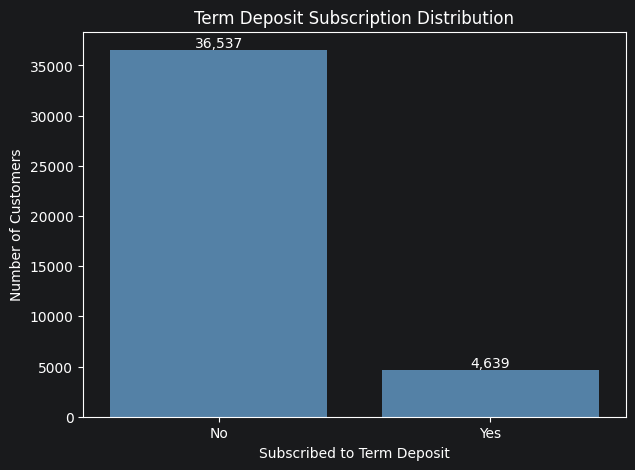

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df,x="y",order=["no", "yes"],color="steelblue")
ax.bar_label(ax.containers[0],labels=[f"{int(value):,}" for value in ax.containers[0].datavalues])
plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

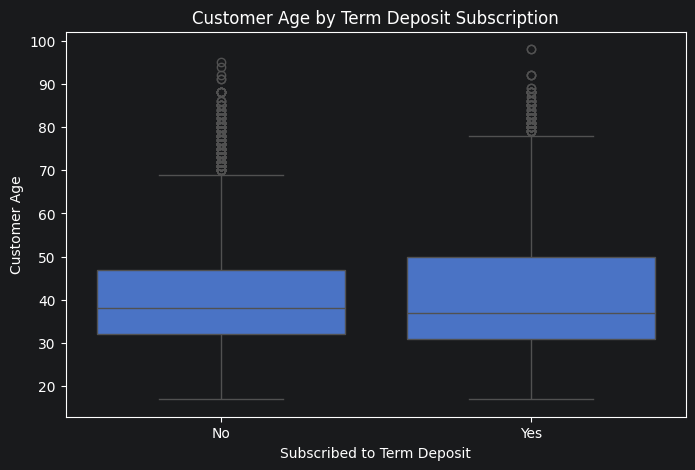

In [141]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x="y",y="age")
plt.title("Customer Age by Term Deposit Subscription")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Customer Age")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

Subscribers and non-subscribers have similar typical ages. However, subscriber ages are more widely distributed, as shown by their higher standard deviation.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

#### Business Objective

 Use pre-contact customer information to identify customers most likely to subscribe to a term deposit, helping the bank reduce unnecessary calls while retaining as many successful subscriptions as possible.

#### Assignment Objective

Compare KNN, logistic regression, decision tree, and SVM.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

We will begin by selecting only the bank client data features, input variables 1 to 7 in the description.

In [142]:
bank_features = ["age","job","marital","education","default","housing","loan"]

# X will contain the seven input features
X = df[bank_features].copy()
# y is the outcome or target we want to predict
y = df["y"].copy()
X.head()

,age,job,marital,education,default,housing,loan
0,56,housemaid,married,basic.4y,no,no,no
1,57,services,married,high.school,unknown,no,no
2,37,services,married,high.school,no,yes,no
3,40,admin.,married,basic.6y,no,no,no
4,56,services,married,high.school,no,no,yes


Now we will encode the target variable, if the customer did not subscribe, we will assign a value of 0, if they did subscribe we will assign a value of 1.

In [143]:
y = y.map({
    "no": 0,
    "yes": 1
})
y.value_counts(dropna=False)

y
0    36537
1     4639
Name: count, dtype: int64

Next, we will use `StandardScaler` to put age on a standardized scale and `OneHotEncoder` to encode the categorical features.

In [144]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
numeric_features = ["age"]
categorical_features = ["job", "marital", "education", "default", "housing", "loan"]
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (OneHotEncoder(handle_unknown="ignore"), categorical_features)
)
preprocessor

ColumnTransformer(transformers=[('standardscaler', StandardScaler(), ['age']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['job', 'marital', 'education', 'default',
                                  'housing', 'loan'])])

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

We will reserve 20% of the data for testing and set the random state to 42. We will also stratify the split to ensure that the proportion of target classes in the training and test sets are similar to the original dataset.

In [145]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("Training target %:")
print(y_train.value_counts(normalize=True))

print("Test target %:")
print(y_test.value_counts(normalize=True))

Training set: (32940, 7)
Test set: (8236, 7)
Training target %:
y
0    0.887341
1    0.112659
Name: proportion, dtype: float64
Test target %:
y
0    0.887324
1    0.112676
Name: proportion, dtype: float64


We split the data in:

- 32,940 rows for training
- 8,236 rows for testing
- Both contain almost the same proportion of target classes (around 88.7% for class 0 and 11.3% for class 1).

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

To define a baseline, we will use a `DummyClassifier` with the `most_frequent` strategy.

In [146]:
from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_accuracy = baseline_model.score(X_test, y_test)
baseline_accuracy

0.8873239436619719

As expected, the `DummyClassifier` predicted every observation as the majority class (class 0 – no subscription). The result is a baseline accuracy of 88.73%.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.

In [147]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
logistic_model = make_pipeline(
    preprocessor,
    LogisticRegression()
)
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(), ['age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan'])])),
                ('logisticregression', LogisticRegression())])

### Problem 9: Score the Model

What is the accuracy of your model?

Now that the model is fit, we can score it.

In [148]:
logistic_accuracy = logistic_model.score(X_test, y_test)
print(f"Logistic regression accuracy: {logistic_accuracy:.4f}")
print(f"Baseline accuracy:            {baseline_accuracy:.4f}")
print(f"Difference:                   {logistic_accuracy - baseline_accuracy:.4f}")

Logistic regression accuracy: 0.8873
Baseline accuracy:            0.8873
Difference:                   0.0000


Our logistic regression model achieved 88.73% accuracy, which is the same as the dummy baseline. This indicates that our model is not performing better than a simple majority class classifier. To understand why, let's examine the predictions made by the model.

In [149]:
logistic_predictions = logistic_model.predict(X_test)
pd.Series(logistic_predictions).value_counts()

0    8236
Name: count, dtype: int64

This means that the logistic regression classifier predicted all 8,236 test observations as class 0 and none as class 1.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

We will build a dictionary of models to compare their performance, each model will use its default settings and will work on a cloned preprocessor.

In [150]:
from sklearn.base import clone
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
models = {
    "Logistic Regression": make_pipeline(
        clone(preprocessor),
        LogisticRegression()
    ),
    "KNN": make_pipeline(
        clone(preprocessor),
        KNeighborsClassifier()
    ),
    "Decision Tree": make_pipeline(
        clone(preprocessor),
        DecisionTreeClassifier(random_state=42)
    ),
    "SVM": make_pipeline(
        clone(preprocessor),
        SVC()
    )
}
models

{'Logistic Regression': Pipeline(steps=[('columntransformer',
                  ColumnTransformer(transformers=[('standardscaler',
                                                   StandardScaler(), ['age']),
                                                  ('onehotencoder',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['job', 'marital',
                                                    'education', 'default',
                                                    'housing', 'loan'])])),
                 ('logisticregression', LogisticRegression())]),
 'KNN': Pipeline(steps=[('columntransformer',
                  ColumnTransformer(transformers=[('standardscaler',
                                                   StandardScaler(), ['age']),
                                                  ('onehotencoder',
                                                   OneHotEncoder(handle_unknown='i

Now we will fit each model and measure the training time, training accuracy, and test accuracy.

In [151]:
from time import perf_counter
results = []
for model_name, model in models.items():
    start_time = perf_counter()
    model.fit(X_train, y_train)
    train_time = perf_counter() - start_time
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)
    results.append({
        "Model": model_name,
        "Train Time": train_time,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })
results_df = pd.DataFrame(results)
results_df.round(4)

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.0616,0.8873,0.8873
1,KNN,0.0304,0.8903,0.8759
2,Decision Tree,0.3545,0.9176,0.8635
3,SVM,32.3850,0.8881,0.8878


- SVM achieved the highest test accuracy at 88.78%, slightly exceeding the 88.73% dummy baseline, but it was by far the slowest model to train at approximately 31.60 seconds.
- Logistic regression matched the 88.73% baseline and predicted no subscriptions, so its apparently high accuracy is misleading.
- KNN had the fastest fit time at approximately 0.03 seconds, although its test accuracy was lower at 87.59%.
- The decision tree had the highest training accuracy at 91.76% but the lowest test accuracy at 86.35%, providing the clearest evidence of overfitting.

Only SVM exceeded the majority-class baseline, and the improvement was very small.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

#### Metrics we will examine to improve our models

- Precision: Among customers predicted to subscribe, how many actually subscribed?
- Recall: Among customers who actually subscribed, how many did we predict would subscribe?
- F1: Balances precision and recall
- Balanced Accuracy: Prevent the large class imbalance in the data (`no` or `0` class dominating the result)

#### Idea

1. Calculate classification metrics
2. Determine which model handles both classes well (as we have already known, they are imbalanced)
3. Select a primary metric
4. Use `GridSearchCV` to tune model settings using only the training data
5. Evaluate the improved model


In [152]:
# 1. Calculate classification metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
metric_results = []
for model_name, model in models.items():
    predictions = model.predict(X_test)
    metric_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0)
    })
metrics_df = pd.DataFrame(metric_results)
metrics_df.sort_values("Balanced Accuracy", ascending=False).round(4)


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1
2,Decision Tree,0.8635,0.5252,0.2278,0.0884,0.1273
1,KNN,0.8759,0.5204,0.2740,0.0614,0.1004
3,SVM,0.8878,0.5045,0.6429,0.0097,0.0191
0,Logistic Regression,0.8873,0.5000,0.0000,0.0000,0.0000


The previous table shows that none of the models handles subscribers well:

- Decision tree has the highest balanced accuracy 52.52%, recall (8.84%) and F1 score (12.73%)
- SVM identifies only 0.97% of subscribers
- Logistic regression identifies no subscribers

These results confirm that ordinary accuracy is misleading for this imbalanced dataset. None of the models handles class `1` effectively.

#### Hyperparameter tuning

For hyperparameter tuning, we will use balanced accuracy as the primary scoring metric because it gives equal importance to both target classes.

First, we will tune the decision tree model. We will look for the best `max_depth`, `min_samples_leaf` and `class_weight` hyperparameters to improve the model's performance.

In [153]:
from sklearn.model_selection import GridSearchCV
tree_pipeline = make_pipeline(
    clone(preprocessor),
    DecisionTreeClassifier(random_state=42)
)
tree_param_grid = {
    "decisiontreeclassifier__max_depth": [3, 5, 10, None],
    "decisiontreeclassifier__min_samples_leaf": [1, 5, 20],
    "decisiontreeclassifier__class_weight": [None, "balanced"]
}
tree_grid = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)
tree_grid.fit(X_train, y_train)
print("Best parameters:", tree_grid.best_params_)
print("Best cross-validation balanced accuracy:", round(tree_grid.best_score_, 4))

Best parameters: {'decisiontreeclassifier__class_weight': 'balanced', 'decisiontreeclassifier__max_depth': 10, 'decisiontreeclassifier__min_samples_leaf': 20}
Best cross-validation balanced accuracy: 0.5985


The grid search achieved a mean cross-validation balanced accuracy of 59.85% using the training folds. We must evaluate the selected model on the test set before comparing it directly with the original tree.

In [154]:
best_tree = tree_grid.best_estimator_
best_tree_predictions = best_tree.predict(X_test)
tuned_tree_result = pd.DataFrame([{
    "Model": "Tuned Decision Tree",
    "Accuracy": accuracy_score(y_test, best_tree_predictions),
    "Balanced Accuracy": balanced_accuracy_score(y_test, best_tree_predictions),
    "Precision": precision_score(y_test, best_tree_predictions, zero_division=0),
    "Recall": recall_score(y_test, best_tree_predictions, zero_division=0),
    "F1": f1_score(y_test, best_tree_predictions, zero_division=0)
}])
tree_comparison = pd.concat([
    metrics_df[metrics_df["Model"] == "Decision Tree"],
    tuned_tree_result
], ignore_index=True)
tree_comparison.round(4)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1
0,Decision Tree,0.8635,0.5252,0.2278,0.0884,0.1273
1,Tuned Decision Tree,0.6844,0.5992,0.1760,0.4892,0.2589


On the same test set, the tuned decision tree increased balanced accuracy from 52.52% to 59.92%, recall from 8.84% to 48.92%, and F1-score from 12.73% to 25.89%. This is a substantial improvement in identifying subscribers.

The trade-off is that overall accuracy decreased from 86.35% to 68.44%, while precision decreased from 22.78% to 17.60%. The tuned model detects more potential subscribers but also incorrectly labels more non-subscribers as subscribers.

#### Confusion Matrix Comparison

We can use a confusion matrix to compare the performance of the default decision tree and the tuned one to translate the results into actual customer counts.

In [155]:
from sklearn.metrics import confusion_matrix
default_tree_predictions = models["Decision Tree"].predict(X_test)
confusion_comparison = pd.DataFrame(
    [
        confusion_matrix(y_test, default_tree_predictions).ravel(),
        confusion_matrix(y_test, best_tree_predictions).ravel()
    ],
    index=["Default Decision Tree", "Tuned Decision Tree"],
    columns=[
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ]
)
confusion_comparison

,True Negatives,False Positives,False Negatives,True Positives
Default Decision Tree,7030,278,846,82
Tuned Decision Tree,5183,2125,474,454


- The default decision tree classified 360 customers as likely subscribers (278 + 82) and correctly identified 82 actual subscribers. It missed 846 subscribers.
- The tuned decision tree classified 2,579 customers as likely subscribers (2,125 + 454) and correctly identified 454 actual subscribers. It reduced the number of missed subscribers from 846 to 474.

Therefore, tuning identified 372 additional subscribers (454 - 82), but it also produced 1,847 additional false positives (2,125 – 278) and would require 2,219 additional marketing calls (2,579 - 360). The tuned model is preferable when identifying more subscribers is the priority. If minimizing unnecessary calls is more important, the bank should consider the lower precision and select a stricter decision threshold.